In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
trips = pd.read_csv('../../data/data/processed/trips.csv')

In [3]:
trips.head()

,duration,start_time,end_time,start_station,end_station,plan_duration,trip_route_category,passholder_type,bike_type
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,One Way,Indego30,electric
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,electric
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,standard


In [4]:
trips['start_time'] = pd.to_datetime(trips['start_time'])

In [5]:
trips['end_time'] = pd.to_datetime(trips['end_time'])

In [6]:
trips.dtypes

duration                        int64
start_time             datetime64[us]
end_time               datetime64[us]
start_station                   int64
end_station                     int64
plan_duration                   int64
trip_route_category               str
passholder_type                   str
bike_type                         str
dtype: object

In [7]:
trips.shape

(6518098, 9)

In [8]:
trips['plan_duration'].value_counts()

plan_duration
30     4126689
365    1813734
1       573226
180       2824
7         1289
300        333
240          2
2            1
Name: count, dtype: int64

In [9]:
trips[('trip_route_category')].value_counts()

trip_route_category
One Way       6016921
Round Trip     501177
Name: count, dtype: int64

In [10]:
trips['passholder_type'].value_counts()

passholder_type
Indego30      4129737
Indego365     1813410
Day Pass       438110
Walk-up        135116
IndegoFlex         13
Name: count, dtype: int64

In [11]:
trips['bike_type'].value_counts()

bike_type
standard    3296263
electric    3221835
Name: count, dtype: int64

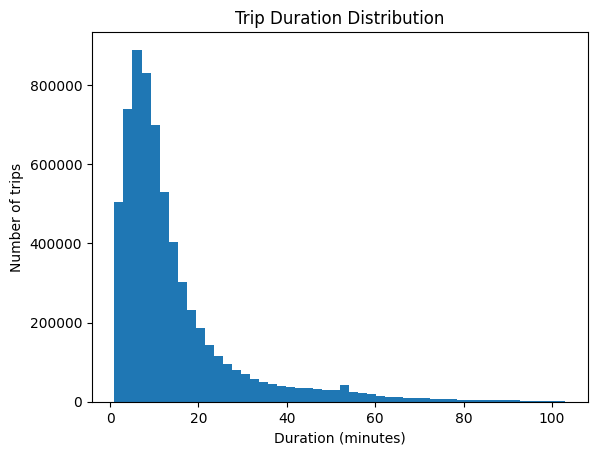

In [12]:
clean = trips[trips["duration"] <= trips["duration"].quantile(0.99)]

plt.figure()
plt.hist(clean["duration"], bins=50)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.title("Trip Duration Distribution")
plt.show()

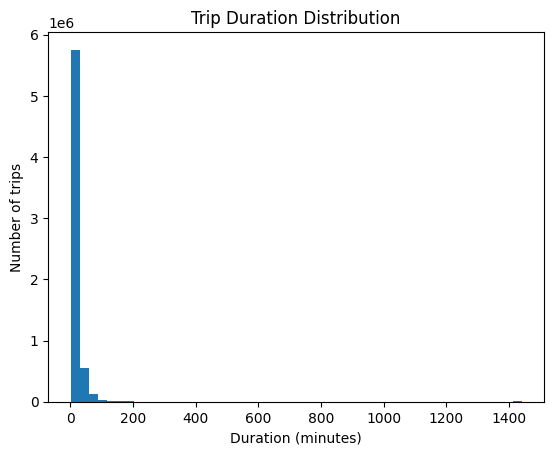

In [13]:
plt.figure()
plt.hist(trips["duration"], bins=50)
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of trips")
plt.title("Trip Duration Distribution")
plt.show()

In [14]:
sum(trips['duration']>=100)

69326

In [15]:
sum(trips['duration']<=2)

284167

Date and time

In [16]:
trips['st_year'] = trips['start_time'].dt.year
trips['st_month'] = trips['start_time'].dt.month
trips['st_day'] = trips['start_time'].dt.day
trips['st_hour'] = trips['start_time'].dt.hour
trips['st_minute'] = trips['start_time'].dt.minute

In [17]:
trips['end_year'] = trips['end_time'].dt.year
trips['end_month'] = trips['end_time'].dt.month
trips['end_day'] = trips['end_time'].dt.day
trips['end_hour'] = trips['end_time'].dt.hour
trips['end_minute'] = trips['end_time'].dt.minute

In [18]:
trips['bike_electric'] = (trips['bike_type'].str.lower() == 'electric').astype(int)

In [19]:
trips.head()

,duration,start_time,end_time,start_station,end_station,plan_duration,trip_route_category,passholder_type,bike_type,st_year,st_month,st_day,st_hour,st_minute,end_year,end_month,end_day,end_hour,end_minute,bike_electric
0,11,2020-01-01 00:13:00,2020-01-01 00:24:00,3049,3072,30,One Way,Indego30,electric,2020,1,1,0,13,2020,1,1,0,24,1
1,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric,2020,1,1,0,14,2020,1,1,0,42,1
2,28,2020-01-01 00:14:00,2020-01-01 00:42:00,3124,3053,30,One Way,Indego30,electric,2020,1,1,0,14,2020,1,1,0,42,1
3,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,electric,2020,1,1,0,17,2020,1,1,0,38,1
4,21,2020-01-01 00:17:00,2020-01-01 00:38:00,3005,3018,30,One Way,Indego30,standard,2020,1,1,0,17,2020,1,1,0,38,0


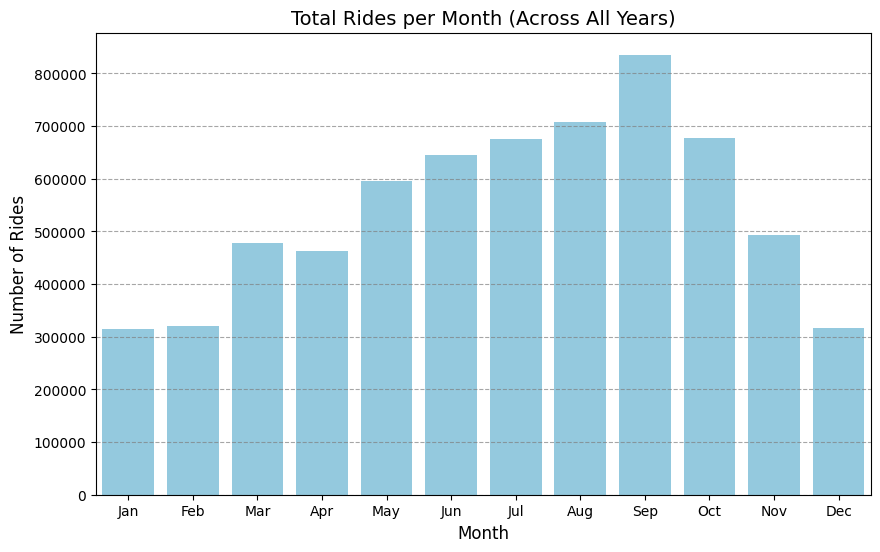

In [20]:
plt.figure(figsize=(10, 6))
sns.countplot(data=trips, x='st_month', color='skyblue')

plt.title('Total Rides per Month (Across All Years)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
# Replace numerical months (1-12) with 3-letter abbreviations
plt.xticks(
    ticks=range(12),
    labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray', zorder=1)
plt.show()

C:\Users\davel\AppData\Local\Temp\ipykernel_27368\334501836.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=trips, x='st_hour', palette='viridis')


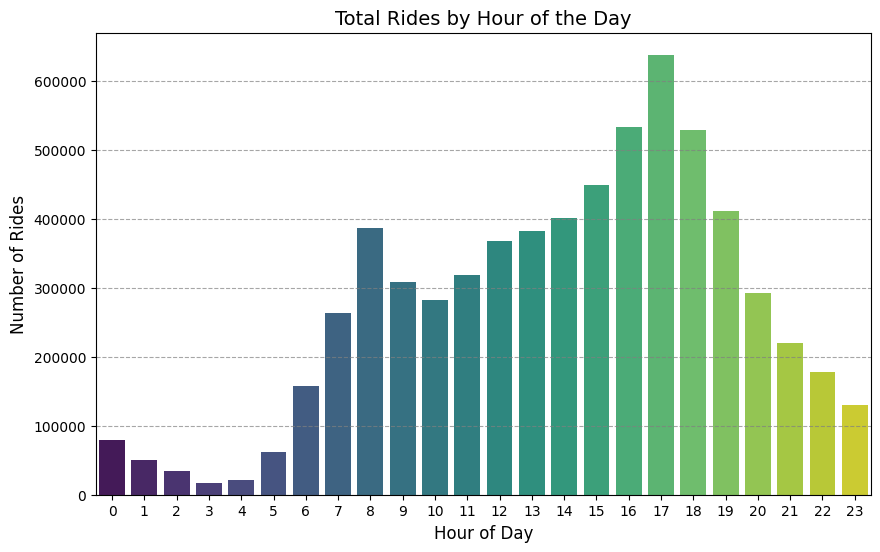

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=trips, x='st_hour', palette='viridis')

plt.title('Total Rides by Hour of the Day', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray', zorder=2)
plt.show()

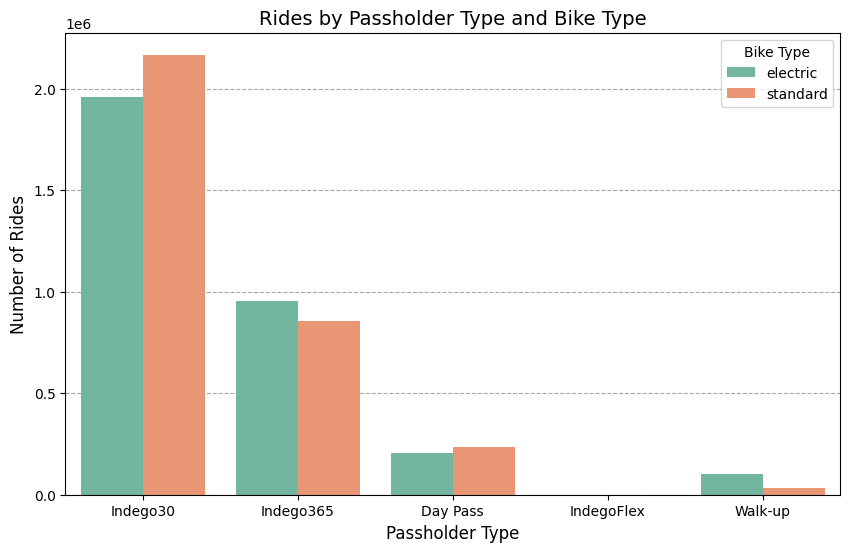

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=trips, x='passholder_type', hue='bike_type', palette='Set2', zorder=2)

plt.title('Rides by Passholder Type and Bike Type', fontsize=14)
plt.xlabel('Passholder Type', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='Bike Type')

# Add y-axis background lines
plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray', zorder=1)

plt.show()

C:\Users\davel\AppData\Local\Temp\ipykernel_27368\2332539100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=trips, x='bike_type', y='duration', palette='Set2', zorder=2)


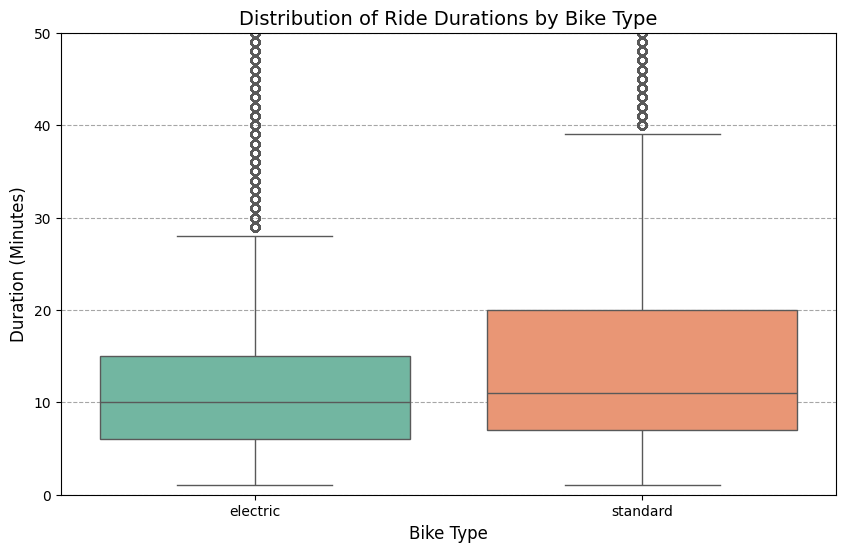

In [23]:
plt.figure(figsize=(10, 6))
# We use the y-axis for duration to keep it vertical
sns.boxplot(data=trips, x='bike_type', y='duration', palette='Set2', zorder=2)

plt.title('Distribution of Ride Durations by Bike Type', fontsize=14)
plt.xlabel('Bike Type', fontsize=12)
plt.ylabel('Duration (Minutes)', fontsize=12)

# Cap the Y-axis at the 95th percentile to hide extreme outliers
y_max = trips['duration'].quantile(0.95)
plt.ylim(0, y_max)

plt.grid(axis='y', linestyle='--', alpha=0.7, color='gray', zorder=1)
plt.show()

C:\Users\davel\AppData\Local\Temp\ipykernel_27368\931314423.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_stations.index, y=top_stations.values, palette='crest', zorder=2)


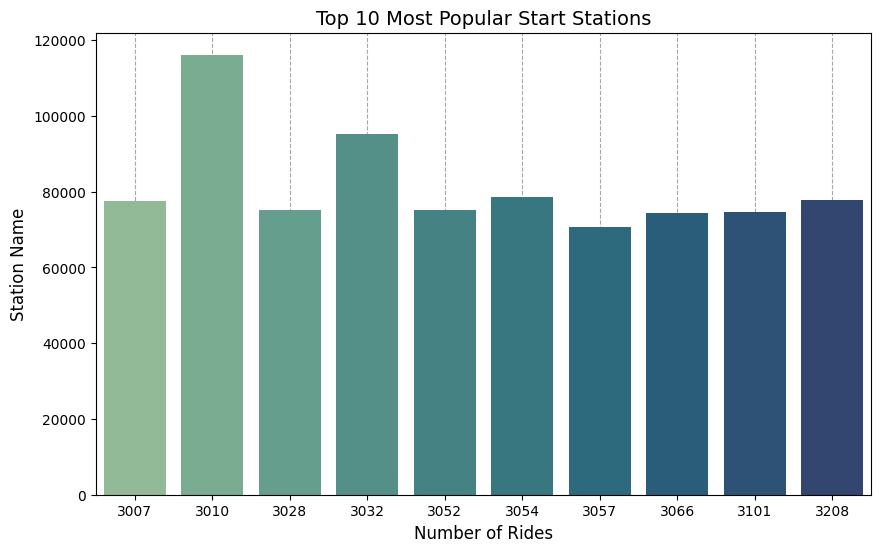

In [24]:
top_stations = trips['start_station'].value_counts().nlargest(10)

plt.figure(figsize=(10, 6))
# Horizontal bar chart: x is the count, y is the station name
sns.barplot(x=top_stations.index, y=top_stations.values, palette='crest', zorder=2)

plt.title('Top 10 Most Popular Start Stations', fontsize=14)
plt.xlabel('Number of Rides', fontsize=12)
plt.ylabel('Station Name', fontsize=12)

# For a horizontal chart, we want vertical grid lines (x-axis)
plt.grid(axis='x', linestyle='--', alpha=0.7, color='gray', zorder=1)
plt.show()

In [25]:
stations = pd.read_csv('../../data/data/processed/stations.csv')

In [26]:
stations[stations['id'] == 3010]

,id,name,latitude,longitude,total_docks,street_address
6,3010,15th & Spruce,39.94711,-75.16618,22.0,1483 Spruce St.


In [32]:
stations[stations['id'] == 3032]

,id,name,latitude,longitude,total_docks,street_address
23,3032,23rd & South,39.94527,-75.17971,20.0,671 S. 23rd St.


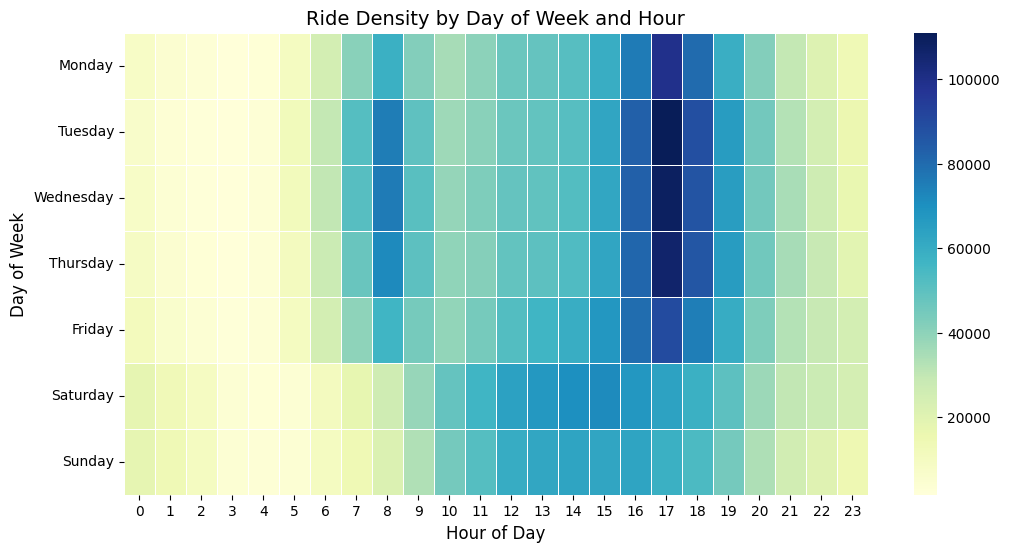

In [27]:
trips['start_day_name'] = trips['start_time'].dt.day_name()

# Create a pivot table counting rides for each day/hour combination
heatmap_data = trips.groupby(['start_day_name', 'st_hour']).size().unstack()

# Reorder the rows so they display Monday -> Sunday instead of alphabetically
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = heatmap_data.reindex(days_order)

plt.figure(figsize=(12, 6))
# 'YlGnBu' is a great color map where darker blue = more rides
sns.heatmap(heatmap_data, cmap='YlGnBu', linewidths=.5)

plt.title('Ride Density by Day of Week and Hour', fontsize=14)
plt.xlabel('Hour of Day', fontsize=12)
plt.ylabel('Day of Week', fontsize=12)
plt.show()

In [31]:
fig = px.scatter_mapbox(
    stations,
    lat="latitude",
    lon="longitude",
    hover_name="name",
   # id = 'id',  # Uncomment if you have a column for station names
    color_discrete_sequence=["#0078FF"], # A nice bright blue marker
    zoom=11,
    height=600
)

# Use OpenStreetMap so you don't need a mapbox API token
fig.update_layout(mapbox_style="open-street-map")

# Remove margins so the map fills the output block
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, title="Bike Station Locations")

fig.show()

C:\Users\davel\AppData\Local\Temp\ipykernel_27368\3916235895.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(
